# 01 — Synthetic Data EDA

Explore the simulated A/B test dataset used to train the conversion elasticity model.

**Key questions:**
- What does the segment distribution look like?
- Is price sensitivity visible in the raw data?
- Are sure-things and persuadables distinguishable on behavioural features alone?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / 'src'))
from shipping.synthetic import (
    PRICE_OPTIONS,
    SEGMENT_NAMES,
    SEGMENT_PARAMS,
    generate_shipping_dataset,
)

sns.set_theme(style='whitegrid', palette='muted')
RESULTS = Path.cwd().parent / 'results'

In [2]:
# Load or generate data
parquet_path = RESULTS / 'sessions.parquet'
if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
    print(f'Loaded {len(df):,} sessions from {parquet_path}')
else:
    df = generate_shipping_dataset(n_sessions=10_000, random_state=42)
    print(f'Generated {len(df):,} sessions (run make train-shipping for full dataset)')

print(f'Columns: {df.columns.tolist()}')
df.head()

Loaded 60,000 sessions from /Users/u0933981/Desktop/Work/commerce-ml-lab/projects/04_shipping_optimization/results/sessions.parquet
Columns: ['session_id', 'segment', 'cart_value', 'n_items', 'is_returning', 'session_depth', 'time_on_checkout', 'device_mobile', 'f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'shipping_price', 'converted', 'cart_margin']


,session_id,segment,cart_value,n_items,is_returning,session_depth,time_on_checkout,device_mobile,f0,f1,f2,f3,f4,f5,shipping_price,converted,cart_margin
0,S0000000,lost_cause,15.00,5,False,6,243.7,True,-0.9631,-0.8793,0.1553,0.4609,1.1258,-0.8118,0.00,False,5.25
1,S0000001,persuadable,122.51,2,True,9,79.9,False,-0.0485,0.3364,0.7938,-1.4815,-1.7317,1.8856,12.99,False,42.88
2,S0000002,sleeping_dog,139.66,3,False,6,384.8,False,0.7698,-0.2809,-1.2526,-2.2190,-0.5405,0.5073,9.99,True,48.88
3,S0000003,lost_cause,63.53,5,True,1,39.7,False,-0.5902,-1.5949,0.6369,1.1549,1.0392,0.0378,2.99,False,22.24
4,S0000004,sure_thing,148.56,3,False,5,189.7,False,0.9335,-0.9942,-0.4960,-0.4312,-0.7056,-0.2427,12.99,True,52.00


## Segment distribution and overall conversion rate

In [3]:
print('Segment distribution:')
print(df['segment'].value_counts(normalize=True).map('{:.1%}'.format))
print(f'\nOverall conversion rate: {df["converted"].mean():.1%}')
print('\nConversion rate by segment:')
print(df.groupby('segment')['converted'].mean().map('{:.1%}'.format))

Segment distribution:
segment
persuadable     29.8%
lost_cause      25.2%
sure_thing      25.0%
sleeping_dog    19.9%
Name: proportion, dtype: str

Overall conversion rate: 42.9%

Conversion rate by segment:
segment
lost_cause       5.1%
persuadable     25.8%
sleeping_dog    58.3%
sure_thing      89.3%
Name: converted, dtype: str


## Price sensitivity — the core signal the model must learn

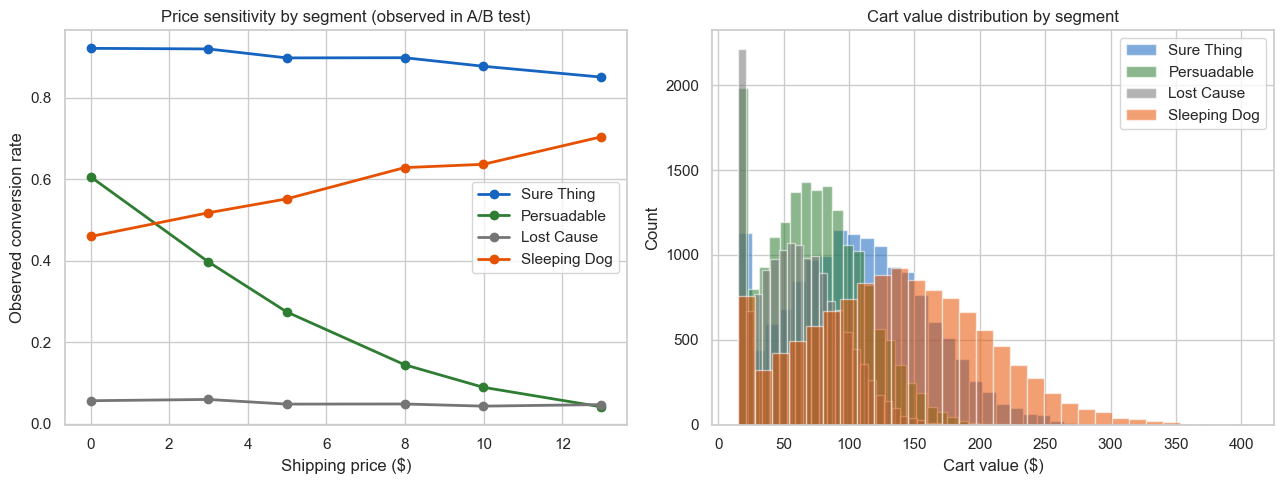

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
seg_colors = {
    'sure_thing': '#1565C0', 'persuadable': '#2E7D32',
    'lost_cause': '#757575', 'sleeping_dog': '#E65100',
}

# Observed conversion rate at each price point, by segment
ax = axes[0]
for seg in SEGMENT_NAMES:
    seg_df = df[df['segment'] == seg]
    rates = seg_df.groupby('shipping_price')['converted'].mean()
    ax.plot(rates.index, rates.values, 'o-', label=seg.replace('_', ' ').title(),
            color=seg_colors[seg], linewidth=2)

ax.set_xlabel('Shipping price ($)')
ax.set_ylabel('Observed conversion rate')
ax.set_title('Price sensitivity by segment (observed in A/B test)')
ax.legend()

# Distribution of cart values by segment
ax2 = axes[1]
for seg in SEGMENT_NAMES:
    ax2.hist(df[df['segment'] == seg]['cart_value'], bins=30, alpha=0.55,
             label=seg.replace('_', ' ').title(), color=seg_colors[seg])
ax2.set_xlabel('Cart value ($)')
ax2.set_ylabel('Count')
ax2.set_title('Cart value distribution by segment')
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS / 'eda_price_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

## Are segments distinguishable on features? (motivating the ML model)

In [5]:
# Feature correlation with segment — how separable are they without price?
feature_cols = ['cart_value', 'session_depth', 'is_returning', 'time_on_checkout']
seg_stats = df.groupby('segment')[feature_cols].mean()
seg_stats['conversion_rate'] = df.groupby('segment')['converted'].mean()

print('Mean feature values by segment:')
print(seg_stats.round(2).to_string())
print('\nNote: segments overlap significantly on individual features.')
print('The model must combine features + price to identify persuadables.')

Mean feature values by segment:
              cart_value  session_depth  is_returning  time_on_checkout  conversion_rate
segment                                                                                 
lost_cause         60.03           4.00          0.20            120.70             0.05
persuadable        73.35           9.00          0.35            120.87             0.26
sleeping_dog      136.71           7.00          0.51            118.90             0.58
sure_thing        106.03          12.02          0.65            119.34             0.89

Note: segments overlap significantly on individual features.
The model must combine features + price to identify persuadables.


## Key takeaways

1. **Sure-things** barely change conversion rate across price points — they'll buy at \$12.99.
2. **Persuadables** show steep price sensitivity — free shipping nearly doubles their conversion rate.
3. **Sleeping dogs** show a slight *positive* correlation between price and conversion (premium signal).
4. **Segments overlap** on individual features — the model needs to combine session context with price to distinguish them.

These patterns motivate a supervised elasticity model rather than a simple heuristic.